1. Configuración del entorno

Acá se importan las librerías necesarias para cargar y transformar los datos, construir pipelines, generar gráficas y comprobar la compatibilidad con el modelo KNN.

También se definen los parámetros principales: una semilla de 42 ("RANDOM_STATE"), una participación de prueba del 20 % ("TEST_SIZE") porque se determinó una distribución 80-20, "Churn" como variable objetivo, "Yes" como clase positiva y "customerID" como identificador.

Además, se localiza automáticamente la raíz del proyecto, se crea la carpeta donde se guardarán los resultados y se calcula el código SHA-256 del dataset. Este código permite comprobar que todos los integrantes estén trabajando con el mismo archivo.

In [1]:
# 1. Entorno, semilla y trazabilidad del dato
from __future__ import annotations

import hashlib
import json
import platform
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
)

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "Churn"
CLASE_POSITIVA = "Yes"
ID_COLUMN = "customerID"


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("No se encontro pyproject.toml")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "preprocesamiento"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
assert DATA_PATH.exists(), "falta el CSV: ejecuta scripts/download_data.py"


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


DATA_SHA256 = sha256(DATA_PATH)
np.random.seed(RANDOM_STATE)
sns.set_theme(context="notebook", style="whitegrid")

print(f"python       : {platform.python_version()}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"csv          : {DATA_PATH.relative_to(PROJECT_ROOT).as_posix()}")
print(f"sha256       : {DATA_SHA256}")
print(f"artefactos   : {ARTIFACTS_DIR.relative_to(PROJECT_ROOT).as_posix()}")

python       : 3.12.10
pandas       : 2.3.3
numpy        : 2.3.5
scikit-learn : 1.9.0
csv          : data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv
sha256       : 88be4b93fbe0cc83421af1c503794c97c342eca914c1576db7c276e61d61358a
artefactos   : artifacts/preprocesamiento


2. Carga y auditoría del dataset

Se carga el archivo inicialmente sin realizar modificaciones. A partir de este se construye una tabla de auditoría que muestra el tipo de dato detectado, la cantidad de valores presentes y faltantes, el número de valores únicos y un ejemplo de cada columna.

También se revisan las dimensiones del dataset, las filas duplicadas, los identificadores repetidos y la distribución de "Churn".

El dataset está conformado por 7.043 registros y 21 columnas. "Churn=Yes" aparece 1.869 veces, lo que corresponde al 26,5 %. Esto quiere decir que, de la totalidad de clientes, solo el 26,5 % cancela el servicio; por lo tanto, existe un desbalance que debe considerarse en la evaluación del modelo.

Esta auditoría es una comprobación mínima del archivo de entrada para asegurar que el preprocesamiento reciba las columnas y clases esperadas. No reemplaza el diccionario de datos, el EDA manual ni el EDA automático que corresponden al notebook 01.

In [2]:
# 2. Carga cruda y auditoría de esquema
raw = pd.read_csv(DATA_PATH)

auditoria = pd.DataFrame(
    {
        "dtype_leido": raw.dtypes.astype(str),
        "no_nulos": raw.notna().sum(),
        "nulos": raw.isna().sum(),
        "valores_unicos": raw.nunique(dropna=False),
        "ejemplo": [raw[col].iloc[0] for col in raw.columns],
    }
)
auditoria.index.name = "columna"

print(f"filas x columnas         : {raw.shape[0]} x {raw.shape[1]}")
print(f"filas duplicadas exactas : {int(raw.duplicated().sum())}")
print(f"{ID_COLUMN} duplicados    : {int(raw[ID_COLUMN].duplicated().sum())}")
print()
print(
    raw[TARGET]
    .value_counts(dropna=False)
    .to_frame("conteo")
    .assign(proporcion=lambda d: (d["conteo"] / len(raw)).round(4))
)

auditoria

filas x columnas         : 7043 x 21
filas duplicadas exactas : 0
customerID duplicados    : 0

       conteo  proporcion
Churn                    
No       5174      0.7346
Yes      1869      0.2654


,dtype_leido,no_nulos,nulos,valores_unicos,ejemplo
columna,,,,,
customerID,object,7043,0,7043,7590-VHVEG
gender,object,7043,0,2,Female
SeniorCitizen,int64,7043,0,2,0
Partner,object,7043,0,2,Yes
Dependents,object,7043,0,2,No
tenure,int64,7043,0,73,1
PhoneService,object,7043,0,2,No
MultipleLines,object,7043,0,3,No phone service
InternetService,object,7043,0,3,DSL


3. Diagnóstico de la variable TotalCharges

La variable "TotalCharges" representa el valor total que se le ha cobrado al cliente durante todo el tiempo que ha permanecido con la empresa. Esta variable tiene relación con "tenure", que indica los meses de permanencia, y con "MonthlyCharges", que representa el cobro mensual.

Aunque intuitivamente debería ser una variable numérica, Pandas la interpreta como texto porque contiene 11 espacios vacíos mezclados con los demás valores. Para detectar estos casos se intenta convertir la columna a número; los valores que no pueden convertirse pasan a representarse como "NaN".

Los 11 registros encontrados tienen "tenure=0", lo que indica que corresponden a clientes nuevos que todavía no tienen un cargo total acumulado. Además, ninguno de ellos presenta "Churn=Yes".

En esta celda únicamente se detectan y diagnostican los valores faltantes. Su tratamiento se realizará posteriormente dentro del pipeline, sin eliminar registros de manera automática.

In [3]:
# 3. TotalCharges: diagnóstico del tipo leído
total_charges_numerico = pd.to_numeric(raw["TotalCharges"], errors="coerce")
no_convertibles = raw.loc[
    total_charges_numerico.isna(),
    [ID_COLUMN, "tenure", "MonthlyCharges", "TotalCharges", TARGET],
]

print(f"no convertibles a número : {len(no_convertibles)}")
if len(no_convertibles):
    print(f"todos con tenure == 0    : {bool((no_convertibles['tenure'] == 0).all())}")
    print(f"alguno con {TARGET}={CLASE_POSITIVA}    : {bool((no_convertibles[TARGET] == CLASE_POSITIVA).any())}")

no_convertibles

no convertibles a número : 11
todos con tenure == 0    : True
alguno con Churn=Yes    : False


columna,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


4. Limpieza previa a la partición

En esta celda se crea una copia del dataset para no alterar la información original almacenada en "raw".

Primero se revisan las 18 columnas de texto y se eliminan los espacios sobrantes. Se encuentran 11 celdas con este problema, correspondientes a los espacios vacíos de "TotalCharges" explicados anteriormente. Después, esta variable se convierte de texto a número decimal ("float64") y esos 11 espacios pasan a representarse correctamente como valores faltantes "NaN".

También se buscan filas completamente duplicadas, pero no se encuentra ninguna. Luego se transforma la variable objetivo "Churn": los clientes con "Churn=Yes" se representan con 1 y los clientes con "Churn=No" con 0. Se utiliza 1 para "Yes" porque representa la clase positiva que se quiere predecir, es decir, los clientes que abandonan el servicio.

Finalmente, "customerID" se retira de las variables predictoras porque es un identificador único y no contiene un patrón que pueda generalizarse. Sin embargo, se conserva por separado para mantener la trazabilidad de cada cliente.

Estas operaciones se realizan antes de dividir los datos porque son deterministas y no calculan estadísticas como medias, medianas o modas. El resultado es una matriz "X" con 7.043 filas y 19 variables predictoras, y una variable objetivo "y" con 1.869 casos positivos.

In [4]:
# 4. Limpieza determinista previa a la partición
REGISTRO_PRESPLIT: list[dict[str, str]] = []


def registrar(operacion: str, detalle: str) -> None:
    REGISTRO_PRESPLIT.append({"operacion": operacion, "detalle": detalle})


datos = raw.copy()

columnas_texto = datos.select_dtypes(include="object").columns
celdas_con_espacios = int(
    sum(
        (datos[col].fillna("") != datos[col].fillna("").str.strip()).sum()
        for col in columnas_texto
    )
)
datos[columnas_texto] = datos[columnas_texto].apply(lambda serie: serie.str.strip())
registrar(
    "normalizacion_texto",
    f"{len(columnas_texto)} columnas revisadas, {celdas_con_espacios} celdas con espacios sobrantes",
)

datos["TotalCharges"] = pd.to_numeric(datos["TotalCharges"], errors="coerce")
registrar(
    "correccion_tipo",
    f"TotalCharges object -> float64, {int(datos['TotalCharges'].isna().sum())} NaN declarados",
)

filas_antes = len(datos)
datos = datos.drop_duplicates()
registrar("duplicados_exactos", f"{filas_antes - len(datos)} filas eliminadas de {filas_antes}")

y = (datos[TARGET] == CLASE_POSITIVA).astype(int)
y.name = TARGET
CUSTOMER_ID = datos[ID_COLUMN]
X = datos.drop(columns=[TARGET, ID_COLUMN])
registrar("codificacion_objetivo", f"{TARGET}: '{CLASE_POSITIVA}' -> 1, resto -> 0")
registrar("exclusion_identificador", f"{ID_COLUMN} retirado de X, conservado aparte")

print(f"X: {X.shape[0]} filas x {X.shape[1]} columnas | y positivos: {int(y.sum())}")
pd.DataFrame(REGISTRO_PRESPLIT)

X: 7043 filas x 19 columnas | y positivos: 1869


,operacion,detalle
0,normalizacion_texto,"18 columnas revisadas, 11 celdas con espacios ..."
1,correccion_tipo,"TotalCharges object -> float64, 11 NaN declarados"
2,duplicados_exactos,0 filas eliminadas de 7043
3,codificacion_objetivo,"Churn: 'Yes' -> 1, resto -> 0"
4,exclusion_identificador,"customerID retirado de X, conservado aparte"


5. Partición de entrenamiento y prueba

En esta celda se divide el dataset en dos conjuntos: 80 % para entrenamiento y 20 % para prueba. Esta distribución permite utilizar la mayor parte de los datos para que el modelo aprenda y conservar una parte independiente para evaluar su capacidad de generalización.

El conjunto de entrenamiento queda formado por 5.634 clientes y se utilizará para calcular medianas, modas, categorías, correlaciones y para entrenar el modelo. El conjunto de prueba contiene 1.409 clientes y solo se utilizará para evaluar el resultado.

Se utiliza una semilla fija de 42 para que la división siempre seleccione los mismos registros. También se usa "stratify=Churn" para conservar la misma proporción de casos positivos en ambos conjuntos. Como resultado, entrenamiento contiene 1.495 casos positivos y prueba contiene 374, manteniendo en ambos una prevalencia aproximada del 26,54 %.

Adicionalmente, se comprueba que ninguna fila aparezca al mismo tiempo en entrenamiento y prueba y que no se pierdan ni se dupliquen registros durante la división.

Finalmente, se genera el archivo "split_referencia.csv", que registra el identificador de cada cliente, el conjunto al que fue asignado y su valor de "Churn". Esto permite que los siguientes notebooks utilicen la misma partición y que la comparación entre pipelines sea justa.

In [5]:
# 5. Partición única 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

assert set(X_train.index).isdisjoint(X_test.index), "filas compartidas entre train y test"
assert len(X_train) + len(X_test) == len(X), "el split perdio o duplico filas"

resumen_split = pd.DataFrame(
    {
        "filas": [len(X_train), len(X_test), len(X)],
        "churn_si": [int(y_train.sum()), int(y_test.sum()), int(y.sum())],
    },
    index=["train", "test", "total"],
)
resumen_split["prevalencia"] = (resumen_split["churn_si"] / resumen_split["filas"]).round(4)

split_referencia = pd.DataFrame(
    {
        ID_COLUMN: CUSTOMER_ID,
        "conjunto": np.where(CUSTOMER_ID.index.isin(X_train.index), "train", "test"),
        TARGET: y,
    }
)
split_referencia.to_csv(ARTIFACTS_DIR / "split_referencia.csv", index=False)

print(f"random_state={RANDOM_STATE} | test_size={TEST_SIZE} | stratify={TARGET}")
print("artefacto: artifacts/preprocesamiento/split_referencia.csv")
resumen_split

random_state=42 | test_size=0.2 | stratify=Churn
artefacto: artifacts/preprocesamiento/split_referencia.csv


,filas,churn_si,prevalencia
train,5634,1495,0.2654
test,1409,374,0.2654
total,7043,1869,0.2654


6. Inventario de variables

En esta celda se clasifican las 19 variables predictoras según el tipo de información que representan. Esta separación es necesaria porque cada grupo recibirá un tratamiento diferente dentro de los pipelines.

"tenure", "MonthlyCharges" y "TotalCharges" se clasifican como numéricas porque representan cantidades. "SeniorCitizen" se separa como una variable binaria que ya está codificada con 0 y 1; estos números indican si el cliente pertenece o no al grupo de adultos mayores y no representan una cantidad continua.

"Partner", "Dependents", "PhoneService" y "PaperlessBilling" son variables binarias con respuestas "Yes" y "No". "gender" también es binaria, pero utiliza las categorías "Female" y "Male".

Las variables relacionadas con servicios adicionales se separan porque pueden contener "Yes", "No" y una tercera respuesta como "No internet service" o "No phone service". Finalmente, "InternetService", "Contract" y "PaymentMethod" se consideran nominales porque tienen varias categorías sin un orden numérico natural.

El inventario se calcula únicamente con entrenamiento. Allí se encuentran 8 valores faltantes en "TotalCharges", 15 variables categóricas y una cardinalidad máxima de 4 categorías. También se comprueba que todas las columnas de "X" estén incluidas exactamente una vez, evitando que alguna quede sin transformar o sea procesada en dos grupos.

In [6]:
# 6. Inventario de columnas por tipo
NUMERICAS = ["tenure", "MonthlyCharges", "TotalCharges"]
YA_BINARIAS = ["SeniorCitizen"]
BINARIAS_SI_NO = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
BINARIA_GENERO = ["gender"]
SERVICIOS_DEPENDIENTES = [
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]
NOMINALES = ["InternetService", "Contract", "PaymentMethod"]

CATEGORICAS = BINARIA_GENERO + BINARIAS_SI_NO + SERVICIOS_DEPENDIENTES + NOMINALES
assert sorted(NUMERICAS + YA_BINARIAS + CATEGORICAS) == sorted(X.columns), (
    "el inventario no cubre exactamente las columnas de X"
)

GRUPOS = {
    "numerica": NUMERICAS,
    "binaria_ya_numerica": YA_BINARIAS,
    "binaria_si_no": BINARIAS_SI_NO,
    "binaria_nominal": BINARIA_GENERO,
    "servicio_dependiente": SERVICIOS_DEPENDIENTES,
    "nominal_multiclase": NOMINALES,
}

inventario = pd.DataFrame(
    [
        {
            "columna": columna,
            "grupo": grupo,
            "dtype": str(X_train[columna].dtype),
            "cardinalidad_train": int(X_train[columna].nunique(dropna=True)),
            "nulos_train": int(X_train[columna].isna().sum()),
            "categorias_train": (
                ", ".join(sorted(map(str, X_train[columna].unique())))
                if X_train[columna].dtype == "object"
                else "-"
            ),
        }
        for grupo, columnas in GRUPOS.items()
        for columna in columnas
    ]
)

cardinalidad_categoricas = inventario.loc[
    inventario["columna"].isin(CATEGORICAS), "cardinalidad_train"
]
print(f"categoricas: {len(CATEGORICAS)} | cardinalidad maxima: {int(cardinalidad_categoricas.max())} niveles")
inventario

categoricas: 15 | cardinalidad maxima: 4 niveles

,columna,grupo,dtype,cardinalidad_train,nulos_train,categorias_train
0,tenure,numerica,int64,73,0,-
1,MonthlyCharges,numerica,float64,1489,0,-
2,TotalCharges,numerica,float64,5275,8,-
3,SeniorCitizen,binaria_ya_numerica,int64,2,0,-
4,Partner,binaria_si_no,object,2,0,"No, Yes"
5,Dependents,binaria_si_no,object,2,0,"No, Yes"
6,PhoneService,binaria_si_no,object,2,0,"No, Yes"
7,PaperlessBilling,binaria_si_no,object,2,0,"No, Yes"
8,gender,binaria_nominal,object,2,0,"Female, Male"
9,MultipleLines,servicio_dependiente,object,3,0,"No, No phone service, Yes"


7. Pipeline mínimo

En esta celda se construye la primera versión del preprocesamiento. Su objetivo es aplicar únicamente las transformaciones necesarias para que todos los datos sean numéricos y el modelo KNN pueda utilizarlos.

Las variables numéricas se completan utilizando la mediana calculada con el conjunto de entrenamiento. Se selecciona la mediana porque es menos sensible que la media a valores muy altos o distribuciones asimétricas. Las variables categóricas se completan con la moda, es decir, con la categoría más frecuente en entrenamiento.

Después, las categorías se convierten a números mediante "OrdinalEncoder". Si aparece una categoría nueva en prueba, se representa con -1 para evitar que el pipeline produzca un error.

El pipeline se ajusta únicamente con entrenamiento y luego aplica las mismas reglas al conjunto de prueba. El resultado conserva 19 columnas en ambos conjuntos. Esta versión permite ejecutar KNN, pero todavía mantiene diferencias grandes de escala y asigna números a categorías que no tienen un orden real; por eso se utiliza como la variante mínima de comparación.

In [7]:
# 7. Variante A: pipeline mínimo ejecutable
def construir_pipeline_minimo() -> ColumnTransformer:
    numerico = SimpleImputer(strategy="median")
    categorico = Pipeline(
        steps=[
            ("imputar", SimpleImputer(strategy="most_frequent")),
            (
                "codificar",
                OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numerico, NUMERICAS + YA_BINARIAS),
            ("cat", categorico, CATEGORICAS),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")


pipeline_minimo = construir_pipeline_minimo()
X_train_minimo = pipeline_minimo.fit_transform(X_train)
X_test_minimo = pipeline_minimo.transform(X_test)

print(f"train {X_train_minimo.shape} | test {X_test_minimo.shape}")
print(f"columnas entrada {X_train.shape[1]} -> salida {X_train_minimo.shape[1]}")
X_train_minimo.head()

train (5634, 19) | test (1409, 19)
columnas entrada 19 -> salida 19


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,gender,Partner,Dependents,PhoneService,PaperlessBilling,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,InternetService,Contract,PaymentMethod
3738,35.0,49.20,1701.65,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,2.0
3151,15.0,75.10,1151.55,0.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0
4860,13.0,40.55,590.35,0.0,1.0,1.0,1.0,0.0,0.0,1.0,2.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,3.0
3867,26.0,73.50,1905.70,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,2.0,2.0,0.0,2.0,2.0,0.0,2.0,1.0
3810,1.0,44.55,44.55,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


8. Escala de la matriz mínima

En esta celda se calculan el mínimo, máximo, media, desviación estándar y rango de cada columna producida por el pipeline mínimo. Esto permite observar qué tan diferentes son las escalas con las que trabajará KNN.

"TotalCharges" tiene un rango mucho mayor que las demás variables y representa aproximadamente el 97,75 % de la suma de los rangos. Este porcentaje no significa que sea la variable más importante para predecir "Churn"; únicamente muestra que sus valores numéricos son mucho más grandes.

Como KNN calcula distancias entre clientes, una variable con valores de miles puede dominar a variables binarias que solo contienen 0 y 1. La gráfica utiliza una escala logarítmica para que todas las columnas puedan visualizarse y demuestra por qué la variante limpia necesita escalar las variables numéricas.

columna dominante: TotalCharges (97.75 % del rango total de 19 columnas)

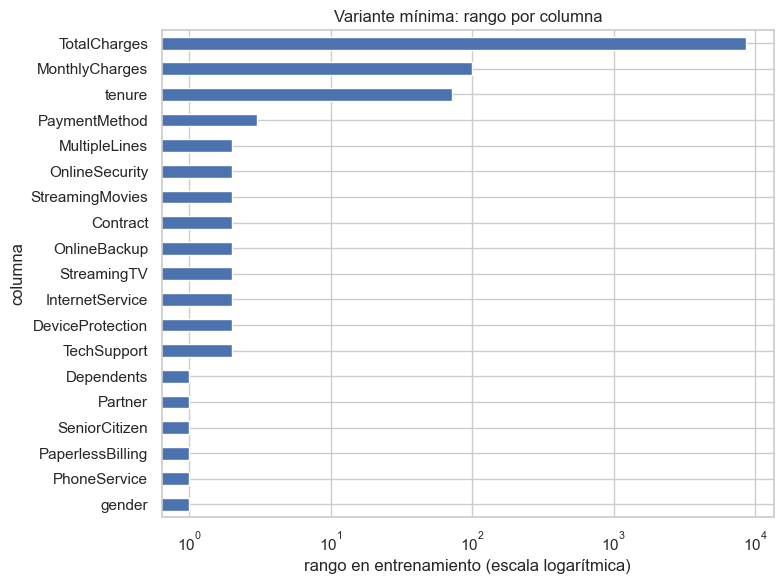

,min,max,mean,std,rango,peso_relativo_%
TotalCharges,18.85,8684.80,2301.320,2277.809,8665.95,97.75
MonthlyCharges,18.40,118.75,64.930,30.138,100.35,1.13
tenure,0.00,72.00,32.485,24.569,72.00,0.81
PaymentMethod,0.00,3.00,1.571,1.069,3.00,0.03
MultipleLines,0.00,2.00,0.948,0.948,2.00,0.02
StreamingMovies,0.00,2.00,0.998,0.886,2.00,0.02
OnlineSecurity,0.00,2.00,0.792,0.861,2.00,0.02
DeviceProtection,0.00,2.00,0.907,0.881,2.00,0.02
TechSupport,0.00,2.00,0.801,0.863,2.00,0.02
OnlineBackup,0.00,2.00,0.918,0.882,2.00,0.02


In [8]:
# 8. Escala de la matriz mínima
escala = X_train_minimo.agg(["min", "max", "mean", "std"]).T
escala["rango"] = escala["max"] - escala["min"]
escala["peso_relativo_%"] = (escala["rango"] / escala["rango"].sum() * 100).round(2)
escala = escala.sort_values("rango", ascending=False)

dominante = escala.index[0]
print(
    f"columna dominante: {dominante} "
    f"({escala.loc[dominante, 'peso_relativo_%']:.2f} % del rango total de {len(escala)} columnas)"
)

fig, ax = plt.subplots(figsize=(8, 6))
escala["rango"].sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xscale("log")
ax.set_xlabel("rango en entrenamiento (escala logarítmica)")
ax.set_ylabel("columna")
ax.set_title("Variante mínima: rango por columna")
plt.tight_layout()
plt.show()

escala.round(3)

9. Agrupación de categorías redundantes

En esta celda se revisan las variables de servicios que contienen las respuestas "No internet service" o "No phone service". Para la característica específica, estas respuestas también significan que el cliente no tiene contratado el servicio, por lo que se agrupan con la categoría "No".

La información sobre la ausencia del servicio principal no se pierde completamente, porque existen columnas separadas como "InternetService" y "PhoneService" que conservan ese dato.

Después se compara la cantidad de categorías antes y después de la agrupación. Siete variables pasan de tres niveles a dos, lo que evita crear siete columnas ficticias adicionales durante la codificación y produce una representación más compacta.

In [9]:
# 9. Variante B, paso 1: colapso de niveles redundantes
EQUIVALENCIAS_NO = {"No internet service": "No", "No phone service": "No"}


def colapsar_no_servicio(bloque: pd.DataFrame) -> pd.DataFrame:
    return bloque.apply(lambda serie: serie.map(lambda v: EQUIVALENCIAS_NO.get(v, v)))


comparacion_colapso = pd.DataFrame(
    {
        "niveles_antes": X_train[SERVICIOS_DEPENDIENTES].nunique(),
        "niveles_despues": colapsar_no_servicio(X_train[SERVICIOS_DEPENDIENTES]).nunique(),
    }
)
comparacion_colapso["dummies_evitadas"] = (
    comparacion_colapso["niveles_antes"] - comparacion_colapso["niveles_despues"]
)

print(f"columnas ficticias evitadas: {int(comparacion_colapso['dummies_evitadas'].sum())}")
comparacion_colapso

columnas ficticias evitadas: 7


,niveles_antes,niveles_despues,dummies_evitadas
columna,,,
MultipleLines,3,2,1
OnlineSecurity,3,2,1
OnlineBackup,3,2,1
DeviceProtection,3,2,1
TechSupport,3,2,1
StreamingTV,3,2,1
StreamingMovies,3,2,1


10. Distribución y valores atípicos

En esta celda se analiza la distribución de "tenure", "MonthlyCharges" y "TotalCharges" utilizando únicamente el conjunto de entrenamiento.

Para cada variable se calculan la media, mediana, desviación estándar, mínimo, máximo, cuartiles, rango intercuartílico y asimetría. También se generan histogramas y diagramas de caja para observar visualmente la forma de los datos.

Los posibles valores atípicos se detectan mediante la regla de 1,5 veces el rango intercuartílico. Un valor que quede por fuera de esos límites se considera potencialmente atípico, pero no se elimina automáticamente porque puede representar un cliente real.

Con esta regla no se encuentran valores atípicos en las variables numéricas de entrenamiento. Este resultado se utilizará posteriormente para seleccionar el tipo de escalador.

Este análisis está limitado a las tres variables numéricas y se utiliza solamente para decidir el escalador del pipeline limpio. No reemplaza el EDA completo del notebook 01, que debe incluir análisis univariado y bivariado, "IQRratio", relación con "Churn", `ProfileReport` y comparación entre EDA manual y automático.

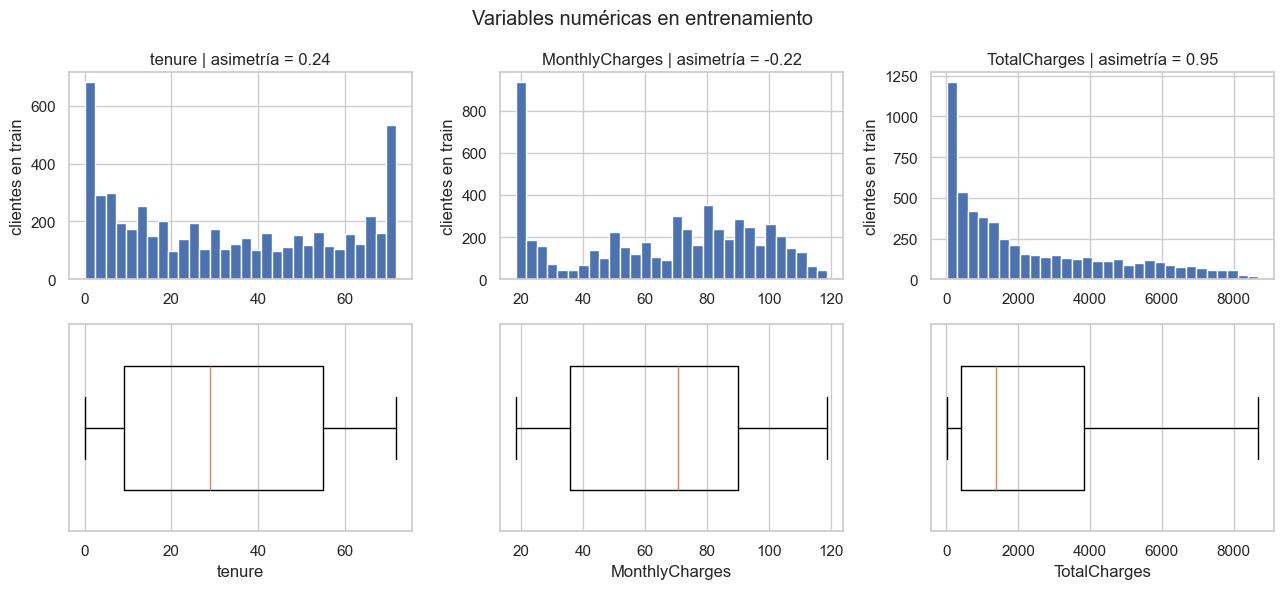

,media,mediana,desv_std,min,max,Q1,Q3,IQR,lim_inferior_1.5IQR,lim_superior_1.5IQR,atipicos,atipicos_%,asimetria,nulos_train
columna,,,,,,,,,,,,,,
tenure,32.485,29.000,24.569,0.00,72.00,9.000,55.000,46.000,-60.000,124.000,0,0.0,0.237,0
MonthlyCharges,64.930,70.500,30.138,18.40,118.75,35.662,90.000,54.338,-45.844,171.506,0,0.0,-0.224,0
TotalCharges,2302.604,1398.125,2279.173,18.85,8684.80,407.275,3838.612,3431.338,-4739.731,8985.619,0,0.0,0.948,8


In [10]:
# 10. Variante B, paso 2: distribución, asimetría y atípicos en entrenamiento
filas_distribucion = []
for columna in NUMERICAS:
    serie = X_train[columna].dropna()
    q1, q2, q3 = serie.quantile([0.25, 0.50, 0.75])
    iqr = q3 - q1
    limite_inferior, limite_superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = int(((serie < limite_inferior) | (serie > limite_superior)).sum())
    filas_distribucion.append(
        {
            "columna": columna,
            "media": serie.mean(),
            "mediana": q2,
            "desv_std": serie.std(),
            "min": serie.min(),
            "max": serie.max(),
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lim_inferior_1.5IQR": limite_inferior,
            "lim_superior_1.5IQR": limite_superior,
            "atipicos": atipicos,
            "atipicos_%": round(atipicos / len(serie) * 100, 2),
            "asimetria": serie.skew(),
            "nulos_train": int(X_train[columna].isna().sum()),
        }
    )

distribucion_numericas = pd.DataFrame(filas_distribucion).set_index("columna")

fig, axes = plt.subplots(2, len(NUMERICAS), figsize=(13, 6))
for indice, columna in enumerate(NUMERICAS):
    serie = X_train[columna].dropna()
    axes[0, indice].hist(serie, bins=30, color="#4C72B0")
    axes[0, indice].set_title(f"{columna} | asimetría = {serie.skew():.2f}")
    axes[0, indice].set_ylabel("clientes en train")
    axes[1, indice].boxplot(serie, vert=False, widths=0.6)
    axes[1, indice].set_xlabel(columna)
    axes[1, indice].set_yticks([])
fig.suptitle("Variables numéricas en entrenamiento")
plt.tight_layout()
plt.show()

distribucion_numericas.round(3)

11. Correlación de Pearson y Spearman

En esta celda se calculan las correlaciones de Pearson y Spearman entre las variables numéricas de entrenamiento. Pearson permite observar relaciones lineales, mientras que Spearman analiza si las variables aumentan o disminuyen siguiendo un orden similar, aunque la relación no sea completamente lineal.

Se define un umbral de 0,95 en valor absoluto para identificar relaciones casi redundantes. La relación más alta aparece entre "tenure" y "TotalCharges", con 0,829 en Pearson y 0,891 en Spearman. Esto tiene sentido porque los cargos totales normalmente aumentan a medida que el cliente permanece más meses en la empresa.

Ninguna pareja supera el umbral de 0,95. Por esta razón no se elimina ninguna variable basándose únicamente en la correlación y se continúa con el análisis de multicolinealidad mediante VIF.

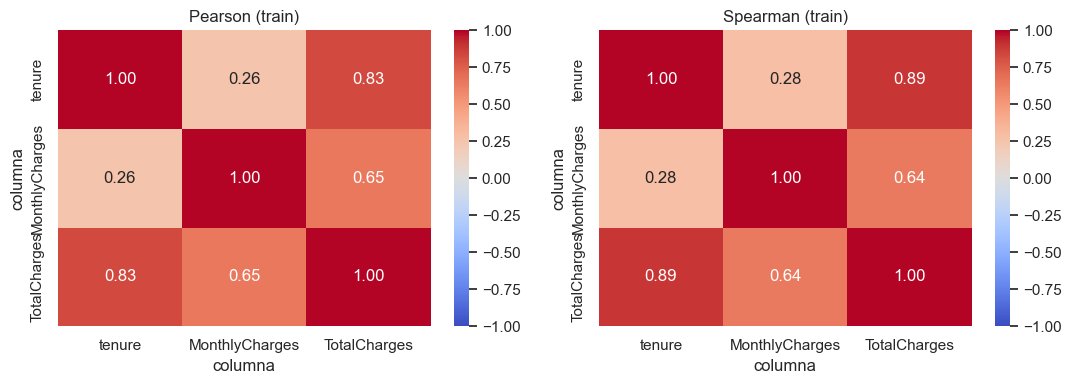

umbral |r| >= 0.95 | pares que lo superan: 0


,variable_a,variable_b,pearson,spearman,supera_umbral
1,tenure,TotalCharges,0.829,0.891,False
2,MonthlyCharges,TotalCharges,0.654,0.642,False
0,tenure,MonthlyCharges,0.257,0.284,False


In [11]:
# 11. Variante B, paso 3: correlación de Pearson y Spearman
UMBRAL_CORRELACION = 0.95

numericas_train = X_train[NUMERICAS]
pearson = numericas_train.corr(method="pearson")
spearman = numericas_train.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, matriz, titulo in zip(axes, [pearson, spearman], ["Pearson", "Spearman"]):
    sns.heatmap(matriz, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm", ax=ax)
    ax.set_title(f"{titulo} (train)")
plt.tight_layout()
plt.show()

pares = []
for i, a in enumerate(NUMERICAS):
    for b in NUMERICAS[i + 1 :]:
        pares.append(
            {
                "variable_a": a,
                "variable_b": b,
                "pearson": pearson.loc[a, b],
                "spearman": spearman.loc[a, b],
                "supera_umbral": bool(abs(pearson.loc[a, b]) >= UMBRAL_CORRELACION),
            }
        )

pares_correlacion = pd.DataFrame(pares).sort_values("pearson", key=abs, ascending=False)
print(f"umbral |r| >= {UMBRAL_CORRELACION} | pares que lo superan: {int(pares_correlacion['supera_umbral'].sum())}")
pares_correlacion.round(3)

12. Análisis del VIF

En esta celda se calcula manualmente el factor de inflación de la varianza (VIF) para medir cuánto puede explicarse cada variable numérica mediante las demás.

Para calcularlo, cada variable se utiliza temporalmente como objetivo de una regresión lineal y las otras variables actúan como predictoras. Con el resultado se aplica la fórmula "VIF = 1 / (1 - R²)".

Se utiliza un umbral de 10 porque a partir de este valor la multicolinealidad se considera severa según el criterio definido para el trabajo. "TotalCharges" obtiene un VIF de 9,575, "tenure" de 5,868 y "MonthlyCharges" de 3,205.

Aunque "TotalCharges" queda cerca del límite y "tenure" presenta un valor alto, ninguna variable alcanza 10. Por esta razón se conservan las tres variables numéricas y no se modifica el umbral después de observar los resultados.

In [12]:
# 12. Variante B, paso 4: VIF calculado a mano
UMBRAL_VIF = 10.0


def calcular_vif(bloque: pd.DataFrame) -> pd.Series:
    # VIF_j = 1 / (1 - R2_j), con R2_j de la regresion lineal de X_j contra el resto
    valores = {}
    for columna in bloque.columns:
        otras = bloque.drop(columns=columna)
        modelo = LinearRegression().fit(otras, bloque[columna])
        r2 = modelo.score(otras, bloque[columna])
        valores[columna] = np.inf if r2 >= 1 - 1e-12 else 1 / (1 - r2)
    return pd.Series(valores, name="VIF").sort_values(ascending=False)


def interpretar_vif(valor: float) -> str:
    if valor < 1.0001:
        return "1 sin colinealidad"
    if valor < 5:
        return "(1,5) baja o moderada"
    if valor < 10:
        return "[5,10) alta"
    return ">=10 severa"


bloque_vif = X_train[NUMERICAS].fillna(X_train[NUMERICAS].median())

columnas_vigentes = list(NUMERICAS)
descartes_vif: list[str] = []
traza_vif = []

while len(columnas_vigentes) > 1:
    vif = calcular_vif(bloque_vif[columnas_vigentes])
    traza_vif.append(vif.rename(f"ronda_{len(traza_vif) + 1}"))
    peor, valor = vif.index[0], vif.iloc[0]
    if valor < UMBRAL_VIF:
        break
    print(f"ronda {len(traza_vif)}: retira '{peor}' con VIF = {valor:.2f} ({interpretar_vif(valor)})")
    descartes_vif.append(peor)
    columnas_vigentes.remove(peor)

tabla_vif = pd.concat(traza_vif, axis=1)
tabla_vif["lectura_final"] = tabla_vif.iloc[:, -1].map(
    lambda v: interpretar_vif(v) if pd.notna(v) else "retirada en ronda previa"
)

print(f"umbral VIF >= {UMBRAL_VIF}")
print(f"retiradas : {descartes_vif or 'ninguna'}")
print(f"vigentes  : {columnas_vigentes}")
tabla_vif.round(3)

umbral VIF >= 10.0
retiradas : ninguna
vigentes  : ['tenure', 'MonthlyCharges', 'TotalCharges']


,ronda_1,lectura_final
TotalCharges,9.575,"[5,10) alta"
tenure,5.868,"[5,10) alta"
MonthlyCharges,3.205,"(1,5) baja o moderada"


13. Selección del escalador y variables eliminadas

En esta celda se selecciona el escalador que se utilizará en el pipeline limpio. La regla definida indica que se usará "RobustScaler" si alguna variable supera el 5 % de valores atípicos; de lo contrario, se utilizará "MinMaxScaler".

"RobustScaler" sería conveniente cuando existen muchos valores extremos porque trabaja con la mediana y el rango intercuartílico. Como en el análisis anterior el porcentaje máximo de atípicos fue 0 %, se selecciona "MinMaxScaler".

Este escalador lleva las variables numéricas de entrenamiento al intervalo entre 0 y 1. Esto es conveniente para KNN porque las variables binarias también utilizan esos valores y así ninguna característica domina las distancias solamente por su unidad de medida.

También se registra qué columnas fueron eliminadas. En esta ejecución solamente se retira "customerID" por ser un identificador único. No se elimina ninguna variable numérica porque ninguna alcanzó el umbral de VIF igual o superior a 10.

In [13]:
# 13. Variante B, paso 5: escalador y registro de columnas retiradas
UMBRAL_ATIPICOS = 5.0

NUMERICAS_MODELO = [columna for columna in NUMERICAS if columna not in descartes_vif]
peor_atipicos = float(distribucion_numericas.loc[NUMERICAS_MODELO, "atipicos_%"].max())

if peor_atipicos > UMBRAL_ATIPICOS:
    ESCALADOR_NOMBRE = "RobustScaler"
    escalador = RobustScaler()
else:
    ESCALADOR_NOMBRE = "MinMaxScaler"
    escalador = MinMaxScaler()

print(f"atipicos 1.5*IQR maximo : {peor_atipicos:.2f} % (umbral {UMBRAL_ATIPICOS} %)")
print(f"escalador elegido       : {ESCALADOR_NOMBRE}")

REGISTRO_ELIMINADAS = [
    {
        "columna": ID_COLUMN,
        "motivo": "identificador unico por fila",
        "evidencia": f"{raw[ID_COLUMN].nunique()} valores distintos en {len(raw)} filas",
        "variante": "minima y limpia",
    },
    *[
        {
            "columna": columna,
            "motivo": f"VIF >= {UMBRAL_VIF}",
            "evidencia": (
                f"VIF = {traza_vif[0].loc[columna]:.2f} en ronda 1 "
                f"({interpretar_vif(traza_vif[0].loc[columna])})"
            ),
            "variante": "solo limpia",
        }
        for columna in descartes_vif
    ],
]

columnas_eliminadas = pd.DataFrame(REGISTRO_ELIMINADAS)
columnas_eliminadas

atipicos 1.5*IQR maximo : 0.00 % (umbral 5.0 %)
escalador elegido       : MinMaxScaler


,columna,motivo,evidencia,variante
0,customerID,identificador unico por fila,7043 valores distintos en 7043 filas,minima y limpia


14. Pipeline limpio

En esta celda se construye la versión completa del preprocesamiento. Cada grupo de variables recibe un tratamiento diferente de acuerdo con el inventario realizado anteriormente.

Las variables numéricas se completan con la mediana aprendida de entrenamiento y se escalan con "MinMaxScaler". "SeniorCitizen" se conserva directamente porque ya está codificada con 0 y 1.

Las variables binarias se completan con la moda y se convierten mediante "OneHotEncoder". Antes de codificar los servicios, las respuestas "No internet service" y "No phone service" se agrupan con "No". Las variables nominales también se completan con la moda y se convierten en columnas independientes para evitar asignarles un orden numérico que no existe.

El parámetro "handle_unknown=ignore" permite procesar una categoría nueva sin que el pipeline falle. Todo el pipeline se ajusta con entrenamiento y luego transforma prueba utilizando exactamente las mismas reglas.

La matriz limpia queda con 5.634 filas y 23 columnas para entrenamiento, y 1.409 filas y las mismas 23 columnas para prueba. Sus valores quedan en un rango compatible entre 0 y 1.

In [14]:
# 14. Variante B: construcción del pipeline limpio
BINARIAS_LIMPIO = BINARIAS_SI_NO + SERVICIOS_DEPENDIENTES + BINARIA_GENERO


def construir_pipeline_limpio() -> ColumnTransformer:
    numerico = Pipeline(
        steps=[
            ("imputar", SimpleImputer(strategy="median")),
            ("escalar", clone(escalador)),
        ]
    )
    binario = Pipeline(
        steps=[
            (
                "colapsar",
                FunctionTransformer(colapsar_no_servicio, feature_names_out="one-to-one"),
            ),
            ("imputar", SimpleImputer(strategy="most_frequent")),
            (
                "codificar",
                OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False),
            ),
        ]
    )
    nominal = Pipeline(
        steps=[
            ("imputar", SimpleImputer(strategy="most_frequent")),
            (
                "codificar",
                OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numerico, NUMERICAS_MODELO),
            ("bin_numerica", "passthrough", YA_BINARIAS),
            ("bin", binario, BINARIAS_LIMPIO),
            ("nom", nominal, NOMINALES),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")


pipeline_limpio = construir_pipeline_limpio()
X_train_limpio = pipeline_limpio.fit_transform(X_train)
X_test_limpio = pipeline_limpio.transform(X_test)

print(f"train {X_train_limpio.shape} | test {X_test_limpio.shape}")
print(f"columnas: minima {X_train_minimo.shape[1]} vs limpia {X_train_limpio.shape[1]}")
print(f"rango global de la matriz limpia: [{X_train_limpio.min().min():.2f}, {X_train_limpio.max().max():.2f}]")
X_train_limpio.head()

train (5634, 23) | test (1409, 23)
columnas: minima 19 vs limpia 23
rango global de la matriz limpia: [0.00, 1.00]


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,MultipleLines_Yes,OnlineSecurity_Yes,...,StreamingTV_Yes,StreamingMovies_Yes,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0.486111,0.306926,0.194185,0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3151,0.208333,0.565022,0.130707,0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4860,0.180556,0.220727,0.065948,0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3867,0.361111,0.549078,0.217731,0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3810,0.013889,0.260588,0.002966,0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


15. Validaciones de los pipelines

En esta celda se comprueba que las matrices mínima y limpia cumplan las condiciones necesarias para ser utilizadas por KNN.

Se valida que todas las columnas sean numéricas, que no existan valores "NaN" ni infinitos, que entrenamiento y prueba tengan las mismas columnas y que no compartan registros. También se comprueba que los índices originales se mantengan para conservar la trazabilidad.

Las medianas almacenadas dentro del pipeline se comparan con las medianas de entrenamiento. Esto demuestra que la imputación se aprendió únicamente con este conjunto y que no se utilizó información de prueba.

Además, se introduce una categoría desconocida en una copia de prueba para verificar que "handle_unknown=ignore" mantenga la forma de la matriz. Finalmente, se entrena temporalmente un KNN con 7 vecinos sobre ambas variantes para confirmar que puede realizar predicciones sin errores.

Las ocho verificaciones terminan con resultado "OK", por lo que las dos matrices cumplen el contrato técnico definido.

El entrenamiento temporal de KNN en esta celda es únicamente una prueba técnica de compatibilidad. No utiliza "y_test", no calcula métricas y no compara el desempeño de las variantes. El entrenamiento definitivo, la evaluación y la interpretación de resultados corresponden al notebook 03.

In [15]:
# 15. Validaciones: sin fuga, sin NaN, todo numérico
verificaciones = []


def verificar(nombre: str, condicion: bool, detalle: str) -> None:
    verificaciones.append(
        {"verificacion": nombre, "resultado": "OK" if condicion else "FALLA", "detalle": detalle}
    )
    assert condicion, f"{nombre}: {detalle}"


matrices = {
    "minima/train": X_train_minimo,
    "minima/test": X_test_minimo,
    "limpia/train": X_train_limpio,
    "limpia/test": X_test_limpio,
}

no_numericas = {
    nombre: matriz.select_dtypes(exclude="number").columns.tolist()
    for nombre, matriz in matrices.items()
}
verificar(
    "salida_numerica",
    all(len(columnas) == 0 for columnas in no_numericas.values()),
    f"columnas no numericas: {no_numericas}",
)
verificar(
    "sin_nan",
    all(not matriz.isna().any().any() for matriz in matrices.values()),
    "ninguna matriz conserva valores faltantes",
)
verificar(
    "sin_infinitos",
    all(bool(np.isfinite(matriz.to_numpy()).all()) for matriz in matrices.values()),
    "ninguna matriz contiene inf o -inf",
)
verificar(
    "columnas_consistentes",
    list(X_train_minimo.columns) == list(X_test_minimo.columns)
    and list(X_train_limpio.columns) == list(X_test_limpio.columns),
    "train y test comparten nombres y orden de columnas",
)
verificar(
    "indices_intactos",
    X_train_limpio.index.equals(X_train.index)
    and X_test_limpio.index.equals(X_test.index)
    and set(X_train_limpio.index).isdisjoint(X_test_limpio.index),
    "cada fila conserva su indice original y su conjunto",
)

medianas_aprendidas = pd.Series(
    pipeline_limpio.named_transformers_["num"].named_steps["imputar"].statistics_,
    index=NUMERICAS_MODELO,
)
comparacion_medianas = pd.DataFrame(
    {
        "aprendida_por_el_pipeline": medianas_aprendidas,
        "mediana_de_train": X_train[NUMERICAS_MODELO].median(),
        "mediana_del_dataset_completo": X[NUMERICAS_MODELO].median(),
    }
)
comparacion_medianas["igual_a_train"] = np.isclose(
    comparacion_medianas["aprendida_por_el_pipeline"], comparacion_medianas["mediana_de_train"]
)
comparacion_medianas["igual_al_dataset_completo"] = np.isclose(
    comparacion_medianas["mediana_de_train"], comparacion_medianas["mediana_del_dataset_completo"]
)
verificar(
    "ajuste_solo_con_train",
    bool(comparacion_medianas["igual_a_train"].all()),
    "cada estadistico del pipeline reproduce la mediana de train",
)
print(comparacion_medianas.round(3))
print()

X_test_sorpresa = X_test.copy()
X_test_sorpresa.iloc[0, X_test_sorpresa.columns.get_loc("PaymentMethod")] = "categoria_inedita"
with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter("always")
    salida_sorpresa = pipeline_limpio.transform(X_test_sorpresa)
print(f"avisos capturados durante el transform: {len(avisos)}")
verificar(
    "categoria_inedita_tolerada",
    salida_sorpresa.shape == X_test_limpio.shape,
    "handle_unknown='ignore' mantiene la forma de la matriz",
)

for nombre, matriz in [("minima", X_train_minimo), ("limpia", X_train_limpio)]:
    KNeighborsClassifier(n_neighbors=7).fit(matriz, y_train).predict(matriz.head(5))
verificar(
    "compatible_con_knn_k7",
    True,
    "ambas matrices entrenan y predicen sin error",
)

pd.DataFrame(verificaciones)

                aprendida_por_el_pipeline  mediana_de_train  \
tenure                             29.000            29.000   
MonthlyCharges                     70.500            70.500   
TotalCharges                     1398.125          1398.125   

                mediana_del_dataset_completo  igual_a_train  \
tenure                                29.000           True   
MonthlyCharges                        70.350           True   
TotalCharges                        1397.475           True   

                igual_al_dataset_completo  
tenure                               True  
MonthlyCharges                      False  
TotalCharges                        False  

avisos capturados durante el transform: 1


,verificacion,resultado,detalle
0,salida_numerica,OK,"columnas no numericas: {'minima/train': [], 'm..."
1,sin_nan,OK,ninguna matriz conserva valores faltantes
2,sin_infinitos,OK,ninguna matriz contiene inf o -inf
3,columnas_consistentes,OK,train y test comparten nombres y orden de colu...
4,indices_intactos,OK,cada fila conserva su indice original y su con...
5,ajuste_solo_con_train,OK,cada estadistico del pipeline reproduce la med...
6,categoria_inedita_tolerada,OK,handle_unknown='ignore' mantiene la forma de l...
7,compatible_con_knn_k7,OK,ambas matrices entrenan y predicen sin error


16. Tabla de transformaciones

En esta celda se construye una tabla que resume qué tratamiento recibe cada variable en el pipeline mínimo y en el pipeline limpio.

Para cada columna se registra su grupo y si recibe imputación por mediana, imputación por moda, codificación ordinal, codificación one-hot, escalamiento, agrupación de categorías o eliminación.

También se incluyen "customerID", que se excluye por ser un identificador, y "Churn", que se mantiene fuera de "X" porque es la variable que el modelo debe predecir.

La tabla se guarda en el archivo "tabla_transformaciones.csv". Este registro permite revisar las decisiones tomadas y facilita que el notebook de modelado conozca exactamente cómo fue construida cada variante.

In [16]:
# 16. Tabla de transformaciones por columna
def descripcion_limpia(columna: str) -> str:
    if columna in descartes_vif:
        return f"retirada por VIF >= {UMBRAL_VIF}"
    if columna in NUMERICAS_MODELO:
        return f"mediana de train + {ESCALADOR_NOMBRE}"
    if columna in YA_BINARIAS:
        return "passthrough (ya es 0/1)"
    if columna in SERVICIOS_DEPENDIENTES:
        return "colapso 'No * service' -> 'No' + moda + OneHot drop='if_binary'"
    if columna in BINARIAS_SI_NO or columna in BINARIA_GENERO:
        return "moda de train + OneHot drop='if_binary'"
    return "moda de train + OneHot drop='first', handle_unknown='ignore'"


def descripcion_minima(columna: str) -> str:
    if columna in NUMERICAS:
        return "mediana de train, sin escalar"
    if columna in YA_BINARIAS:
        return "passthrough"
    return "moda de train + OrdinalEncoder"


tabla_transformaciones = pd.DataFrame(
    [
        {
            "columna": columna,
            "grupo": grupo,
            "variante_minima": descripcion_minima(columna),
            "variante_limpia": descripcion_limpia(columna),
        }
        for grupo, columnas in GRUPOS.items()
        for columna in columnas
    ]
)
tabla_transformaciones.loc[len(tabla_transformaciones)] = {
    "columna": ID_COLUMN,
    "grupo": "identificador",
    "variante_minima": "excluida",
    "variante_limpia": "excluida",
}
tabla_transformaciones.loc[len(tabla_transformaciones)] = {
    "columna": TARGET,
    "grupo": "objetivo",
    "variante_minima": f"'{CLASE_POSITIVA}' -> 1, resto -> 0 (fuera de X)",
    "variante_limpia": f"'{CLASE_POSITIVA}' -> 1, resto -> 0 (fuera de X)",
}

tabla_transformaciones.to_csv(ARTIFACTS_DIR / "tabla_transformaciones.csv", index=False)
print("artefacto: artifacts/preprocesamiento/tabla_transformaciones.csv")
tabla_transformaciones

artefacto: artifacts/preprocesamiento/tabla_transformaciones.csv


,columna,grupo,variante_minima,variante_limpia
0,tenure,numerica,"mediana de train, sin escalar",mediana de train + MinMaxScaler
1,MonthlyCharges,numerica,"mediana de train, sin escalar",mediana de train + MinMaxScaler
2,TotalCharges,numerica,"mediana de train, sin escalar",mediana de train + MinMaxScaler
3,SeniorCitizen,binaria_ya_numerica,passthrough,passthrough (ya es 0/1)
4,Partner,binaria_si_no,moda de train + OrdinalEncoder,moda de train + OneHot drop='if_binary'
5,Dependents,binaria_si_no,moda de train + OrdinalEncoder,moda de train + OneHot drop='if_binary'
6,PhoneService,binaria_si_no,moda de train + OrdinalEncoder,moda de train + OneHot drop='if_binary'
7,PaperlessBilling,binaria_si_no,moda de train + OrdinalEncoder,moda de train + OneHot drop='if_binary'
8,gender,binaria_nominal,moda de train + OrdinalEncoder,moda de train + OneHot drop='if_binary'
9,MultipleLines,servicio_dependiente,moda de train + OrdinalEncoder,colapso 'No * service' -> 'No' + moda + OneHot...


17. Contrato y exportación de los resultados

En esta celda se crea el contrato que utilizará el notebook de modelado. Allí se guardan el código SHA-256 del dataset, la semilla, la proporción de prueba, la variable objetivo, la clase positiva, la métrica principal y el modelo KNN con 7 vecinos acordado para la comparación.

También se registran los tamaños de entrenamiento y prueba, la prevalencia de "Churn", la cantidad de columnas producidas por cada variante, el escalador seleccionado, los umbrales utilizados y las variables numéricas conservadas o eliminadas.

La variante mínima contiene 19 columnas y la variante limpia contiene 23. Las matrices "X_train", "X_test" y las variables objetivo de ambos conjuntos se exportan como archivos comprimidos, conservando sus índices originales.

Estos archivos permiten que el notebook 03 entrene el mismo modelo sobre las dos variantes sin repetir el preprocesamiento ni cambiar la partición. De esta manera, cualquier diferencia en los resultados podrá relacionarse con el tipo de preparación aplicada a los datos.

El notebook 02 termina con esta exportación. No calcula F1, accuracy, precision, recall ni matrices de confusión. Estas tareas pertenecen al notebook 03.

El notebook 03 debe partir de los seis CSV comprimidos guardados en `artifacts/preprocesamiento/`: "X_train_minimo.csv.gz", "X_test_minimo.csv.gz", "X_train_limpio.csv.gz", "X_test_limpio.csv.gz", "y_train.csv.gz" y "y_test.csv.gz". Debe cargarlos con `index_col=0` y no volver a leer el CSV crudo para construir otro split o repetir las transformaciones.

Por separado, el notebook 01 debe partir del CSV crudo y utilizar "split_referencia.csv" para limitar su EDA a las filas de entrenamiento. De esta manera, el notebook 01 conserva las variables originales para el análisis, mientras que el notebook 03 recibe las matrices ya preparadas para el modelo.

In [17]:
# 17. Contrato y artefactos para el notebook 03
contrato = {
    "dataset_sha256": DATA_SHA256,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "target": TARGET,
    "clase_positiva": CLASE_POSITIVA,
    "metrica_primaria": "f1 de la clase positiva",
    "estimador": "KNeighborsClassifier(n_neighbors=7)",
    "filas_train": int(len(X_train)),
    "filas_test": int(len(X_test)),
    "prevalencia_train": round(float(y_train.mean()), 6),
    "prevalencia_test": round(float(y_test.mean()), 6),
    "columnas_variante_minima": int(X_train_minimo.shape[1]),
    "columnas_variante_limpia": int(X_train_limpio.shape[1]),
    "escalador_variante_limpia": ESCALADOR_NOMBRE,
    "umbral_correlacion": UMBRAL_CORRELACION,
    "umbral_vif": UMBRAL_VIF,
    "umbral_atipicos_pct": UMBRAL_ATIPICOS,
    "numericas_retiradas_por_vif": descartes_vif,
    "numericas_en_el_modelo": NUMERICAS_MODELO,
}

(ARTIFACTS_DIR / "contrato_preprocesamiento.json").write_text(
    json.dumps(contrato, indent=2, ensure_ascii=False), encoding="utf-8"
)

exportables = {
    "X_train_minimo": X_train_minimo,
    "X_test_minimo": X_test_minimo,
    "X_train_limpio": X_train_limpio,
    "X_test_limpio": X_test_limpio,
    "y_train": y_train.to_frame(),
    "y_test": y_test.to_frame(),
}
for nombre, objeto in exportables.items():
    objeto.to_csv(ARTIFACTS_DIR / f"{nombre}.csv.gz", index=True, compression="gzip")

for archivo in sorted(ARTIFACTS_DIR.iterdir()):
    print(f"{archivo.name:38s} {archivo.stat().st_size / 1024:8.1f} KB")

print()
print(json.dumps(contrato, indent=2, ensure_ascii=False))

contrato_preprocesamiento.json              0.7 KB
split_referencia.csv                      136.2 KB
tabla_transformaciones.csv                  2.2 KB
X_test_limpio.csv.gz                       37.7 KB
X_test_minimo.csv.gz                       21.5 KB
X_train_limpio.csv.gz                     147.3 KB
X_train_minimo.csv.gz                      83.5 KB
y_test.csv.gz                               3.7 KB
y_train.csv.gz                             13.8 KB

{
  "dataset_sha256": "88be4b93fbe0cc83421af1c503794c97c342eca914c1576db7c276e61d61358a",
  "random_state": 42,
  "test_size": 0.2,
  "target": "Churn",
  "clase_positiva": "Yes",
  "metrica_primaria": "f1 de la clase positiva",
  "estimador": "KNeighborsClassifier(n_neighbors=7)",
  "filas_train": 5634,
  "filas_test": 1409,
  "prevalencia_train": 0.265353,
  "prevalencia_test": 0.265436,
  "columnas_variante_minima": 19,
  "columnas_variante_limpia": 23,
  "escalador_variante_limpia": "MinMaxScaler",
  "umbral_correlacion": 0.95,
  